# Chapter 2 — Supervised Learning Warm-Up

This notebook accompanies **Chapter 2** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

We follow the Queen's mathematician through her first supervised learning problem: predict the power $y$ of a new weapon from a controlled parameter $x$. The core lessons are:

- A **prediction function** $\hat{g}$ is learnt by minimising a **loss**; the natural choice here is the **residual sum of squares** (RSS).
- Using a more flexible function family always reduces RSS on the training data, but can lead to **overfitting**: the fitted curve chases noise rather than the true trend.
- **Leave-one-out cross-validation** (LOOCV) estimates how well a prediction strategy generalises to unseen data, and reveals a sweet spot between underfitting and overfitting.
- Cross-validation cannot replace **prior knowledge**: a model supported only by its CV score may have done well by fluke — the **winner's curse**.
- **Bootstrapping** quantifies uncertainty in the parameters of a chosen prediction function.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from numpy.polynomial import Polynomial

rng = np.random.default_rng(42)

In [2]:
try:
    import google.colab
    DATA_PATH = "https://inferencebook.github.io/data/"
except ImportError:
    DATA_PATH = "../data/"


---
## 1 · The dataset

> **Book link — §2.1.**  The Queen's inventors test their weapon each day with a different value of a controlled parameter $x$, recording the resulting power $y$.  After 40 tests the dataset $D$ is handed over for analysis.

We load $D$ and plot it to get a first look at the predictor–response relationship.

Training set: n = 40 points
x range: [1.5, 33.7]
y range: [0.9, 47.0]


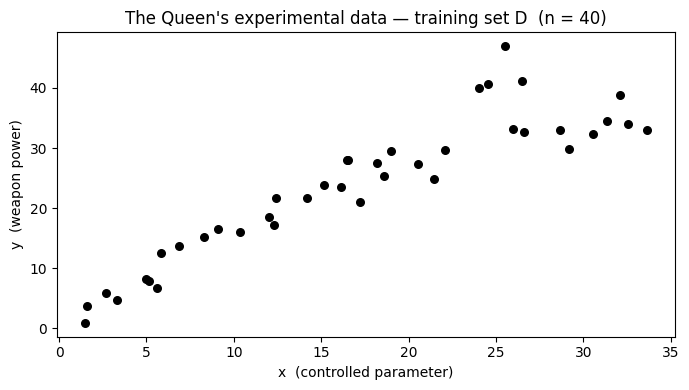

In [3]:
D = pd.read_csv(DATA_PATH + 'queens_data.csv')
x = D['x'].values
y = D['y'].values

print(f'Training set: n = {len(x)} points')
print(f'x range: [{x.min():.1f}, {x.max():.1f}]')
print(f'y range: [{y.min():.1f}, {y.max():.1f}]')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, color='k', s=30, zorder=3)
ax.set_xlabel('x  (controlled parameter)')
ax.set_ylabel('y  (weapon power)')
ax.set_title('The Queen\'s experimental data — training set D  (n = 40)')
plt.tight_layout()
plt.show()

There is a broad upward trend that may flatten or reverse at larger $x$ values.  We need a principled way to fit a prediction function and to choose among candidate function families.

---
## 2 · Fitting curves by minimising RSS

> **Book link — §2.2.**  Given a prediction function $\hat{g}$, the **residual sum of squares** is
> $$\mathrm{RSS}(\hat{g}; D) = \sum_{(x,y)\in D} \bigl(y - \hat{g}(x)\bigr)^2.$$
> Minimising RSS over a family of functions is called **least-squares regression**.  We compare three polynomial families: linear (degree 1), quadratic (degree 2), and degree 15.

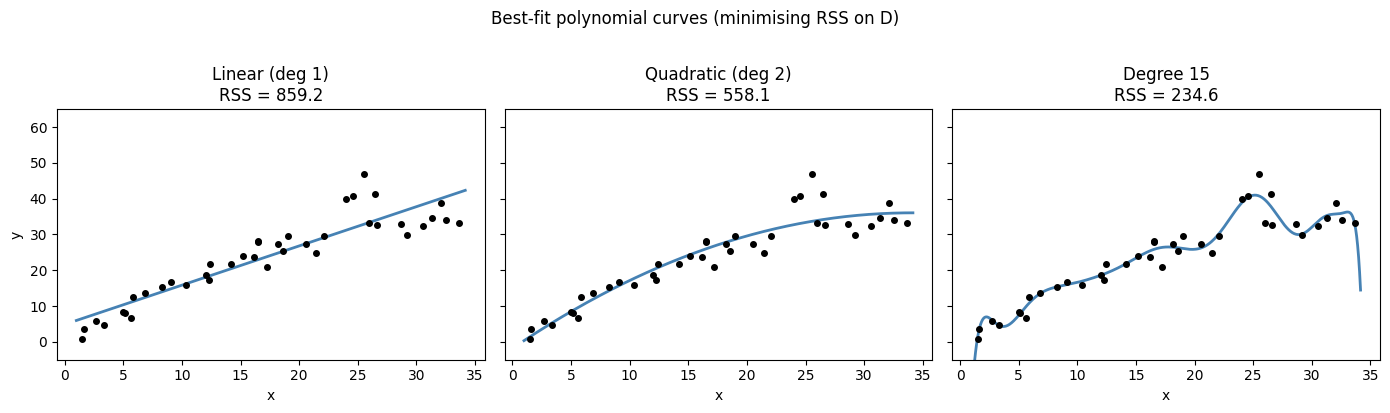

RSS by degree:
  degree  1: RSS = 859.2
  degree  2: RSS = 558.1
  degree 15: RSS = 234.6


In [4]:
def rss(y_true, y_pred):
    return float(np.sum((y_true - y_pred) ** 2))

x_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, deg, label in zip(axes,
                           [1, 2, 15],
                           ['Linear (deg 1)', 'Quadratic (deg 2)', 'Degree 15']):
    c     = Polynomial.fit(x, y, deg)
    r     = rss(y, c(x))
    ax.scatter(x, y, color='k', s=16, zorder=3)
    ax.plot(x_plot, c(x_plot), 'steelblue', linewidth=2)
    ax.set_xlabel('x')
    ax.set_title(f'{label}\nRSS = {r:.1f}')
    ax.set_ylim(-5, 65)

axes[0].set_ylabel('y')
plt.suptitle('Best-fit polynomial curves (minimising RSS on D)', y=1.02)
plt.tight_layout()
plt.show()

print('RSS by degree:')
for deg in [1, 2, 15]:
    c = Polynomial.fit(x, y, deg)
    print(f'  degree {deg:2d}: RSS = {rss(y, c(x)):.1f}')

RSS shrinks monotonically with degree — degree 15 fits the training data most closely.  But does a lower training RSS mean better predictions on tomorrow's unseen data point?

---
## 3 · Sensitivity to noise

> **Book link — §2.2, Figure 2.3.**  If the inventors repeated their experiments, we would not expect identical $y$ values — the measurements bounce around due to noise.  A good prediction strategy should be insensitive to these small fluctuations.

We create a 'perturbed' dataset $D'$ by nudging each $y$ value slightly, then compare how much the fitted curves change.

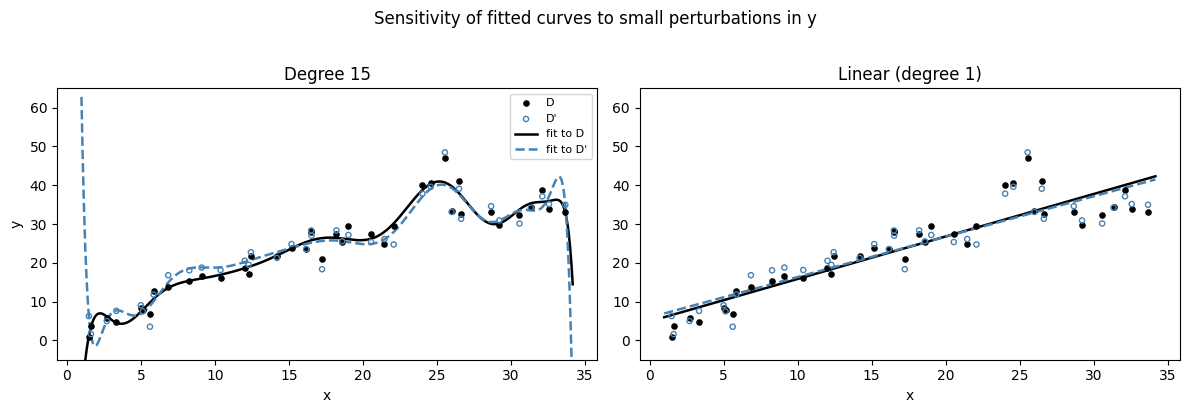

In [5]:
y_prime = y + rng.normal(0, 2.5, len(y))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, deg, title in zip(axes, [15, 1], ['Degree 15', 'Linear (degree 1)']):
    c_orig = Polynomial.fit(x, y,       deg)
    c_pert = Polynomial.fit(x, y_prime, deg)
    ax.scatter(x, y,       color='k',         s=14, zorder=4, label='D')
    ax.scatter(x, y_prime, color='steelblue', s=14, zorder=4,
               facecolors='none', label="D'")
    ax.plot(x_plot, c_orig(x_plot), 'k',         lw=1.8, label='fit to D')
    ax.plot(x_plot, c_pert(x_plot), 'steelblue', lw=1.8,
            linestyle='--', label="fit to D'")
    ax.set_xlabel('x')
    ax.set_title(title)
    ax.set_ylim(-5, 65)

axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)
plt.suptitle('Sensitivity of fitted curves to small perturbations in y', y=1.02)
plt.tight_layout()
plt.show()

The linear curve barely moves, but the degree-15 curve changes significantly. This is the hallmark of overfitting: high sensitivity to the specific values in the training set.

---
## 4 · Cross-validation (LOOCV)

> **Book link — §2.3.**  The key insight: fitting a curve to $n-1$ points and predicting the $n$th mimics the real task of predicting an unseen future point.  Repeating this for every possible held-out point and averaging the squared errors gives the **leave-one-out CV MSE**:
> $$\mathrm{LOOCV\text{-}MSE} = \frac{1}{n}\sum_{i=1}^n \bigl(y_i - \hat{g}_{-i}(x_i)\bigr)^2,$$
> where $\hat{g}_{-i}$ is the curve fitted to all points except $(x_i, y_i)$.

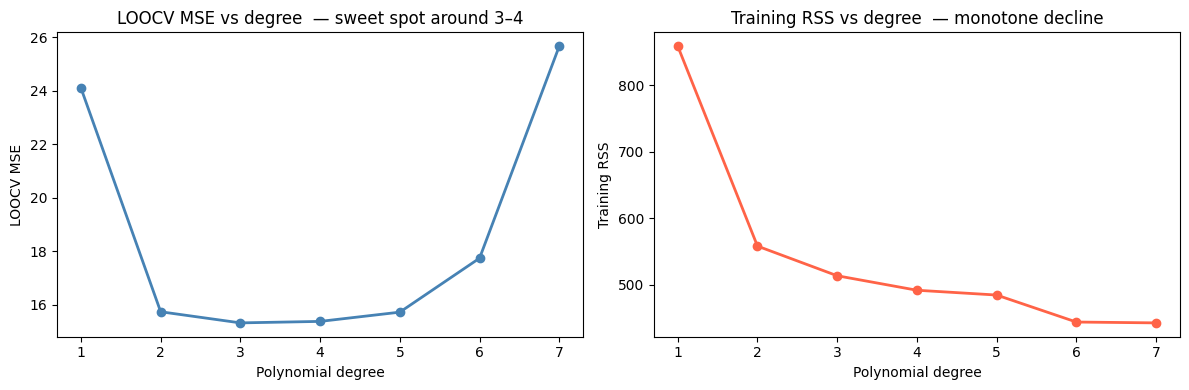

LOOCV MSE by degree:
  degree 1: 24.1
  degree 2: 15.7
  degree 3: 15.3
  degree 4: 15.4
  degree 5: 15.7
  degree 6: 17.7
  degree 7: 25.7


In [6]:
def loocv_mse_poly(x, y, degree):
    n, sq_err = len(x), np.zeros(len(x))
    for i in range(n):
        mask = np.arange(n) != i
        c = Polynomial.fit(x[mask], y[mask], degree)
        sq_err[i] = (y[i] - c(x[i])) ** 2
    return float(sq_err.mean())

degs        = np.arange(1, 8)
loocv_poly  = np.array([loocv_mse_poly(x, y, d) for d in degs])
train_rss   = np.array([rss(y, Polynomial.fit(x, y, d)(x)) for d in degs])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(degs, loocv_poly, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Polynomial degree')
axes[0].set_ylabel('LOOCV MSE')
axes[0].set_title('LOOCV MSE vs degree  — sweet spot around 3–4')

axes[1].plot(degs, train_rss, 'o-', color='tomato', linewidth=2)
axes[1].set_xlabel('Polynomial degree')
axes[1].set_ylabel('Training RSS')
axes[1].set_title('Training RSS vs degree  — monotone decline')

plt.tight_layout()
plt.show()

print('LOOCV MSE by degree:')
for d, m in zip(degs, loocv_poly):
    print(f'  degree {d}: {m:.1f}')

LOOCV MSE first falls (underfitting → better fit) then rises (overfitting → worse generalisation).  Training RSS never rises — it cannot, because a richer family can always fit the same data at least as well.

---
## 5 · Exploiting background knowledge: the AB-MIX family

> **Book link — §2.4.**  Tavern rumours reveal that $x$ is the fraction of substance A in the inventors' powder.  Chemistry predicts a **piecewise-linear** response: power rises linearly from $0$ at $x=0$ to a maximum $y_{\max}$ at an optimum $x_{\mathrm{opt}}$, then falls linearly back to $0$ at $x = 100$.  This defines the AB-MIX family, parameterised by $(x_{\mathrm{opt}},\, y_{\max})$.

Best AB-MIX fit:  x_opt = 25.0,  y_max = 37.6,  RSS = 441.2


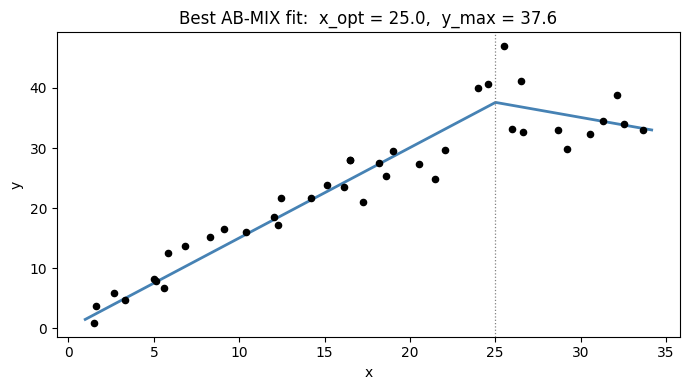

In [7]:
def ab_mix(x, x_opt, y_max):
    """Piecewise-linear AB-MIX prediction function."""
    return np.where(x <= x_opt,
                    y_max * x / x_opt,
                    y_max * (100.0 - x) / (100.0 - x_opt))

def fit_abmix(x_data, y_data, x0=(25.0, 38.0)):
    def obj(p):
        xo, ym = p
        if xo <= 0 or xo >= 100 or ym <= 0:
            return 1e9
        return float(np.sum((y_data - ab_mix(x_data, xo, ym)) ** 2))
    return minimize(obj, x0=list(x0), method='Nelder-Mead',
                    options={'xatol': 0.01, 'fatol': 0.1}).x

x_opt_hat, y_max_hat = fit_abmix(x, y)
rss_abmix = rss(y, ab_mix(x, x_opt_hat, y_max_hat))

print(f'Best AB-MIX fit:  x_opt = {x_opt_hat:.1f},  y_max = {y_max_hat:.1f},  RSS = {rss_abmix:.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, color='k', s=20, zorder=3)
ax.plot(x_plot, ab_mix(x_plot, x_opt_hat, y_max_hat), 'steelblue', linewidth=2)
ax.axvline(x_opt_hat, color='grey', linestyle=':', linewidth=0.9)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Best AB-MIX fit:  x_opt = {x_opt_hat:.1f},  y_max = {y_max_hat:.1f}')
plt.tight_layout()
plt.show()

In [8]:
# LOOCV for AB-MIX — fit the two parameters 40 times, each time leaving one point out
n = len(x)
sq_err_abmix = np.zeros(n)
for i in range(n):
    mask = np.arange(n) != i
    xoi, ymi = fit_abmix(x[mask], y[mask])
    sq_err_abmix[i] = (y[i] - ab_mix(x[i], xoi, ymi)) ** 2
abmix_loocv = float(sq_err_abmix.mean())

best_poly_deg = int(degs[np.argmin(loocv_poly)])
print(f'AB-MIX LOOCV MSE:                              {abmix_loocv:.1f}')
print(f'Best polynomial LOOCV MSE (degree {best_poly_deg}):         {loocv_poly.min():.1f}')

AB-MIX LOOCV MSE:                              12.9
Best polynomial LOOCV MSE (degree 3):         15.3


AB-MIX beats the best polynomial — and it has a physical justification.

---
## 6 · Winner's curse

> **Book link — §2.5.**  Cross-validation over a large search space produces a biased 'winner': the family that happens to do best on this particular dataset probably did so partly by luck, and should not be expected to repeat that performance on future data.

We extend the polynomial search to degree 13 and surface the surprise.

LOOCV MSE for degrees 1–13:
  degree  1:   24.1
  degree  2:   15.7
  degree  3:   15.3
  degree  4:   15.4
  degree  5:   15.7
  degree  6:   17.7
  degree  7:   25.7
  degree  8:   25.3
  degree  9:   15.4
  degree 10:   93.8
  degree 11:   51.5
  degree 12:   25.6
  degree 13:   11.5
  AB-MIX:      12.9

CV winner: degree 13  (LOOCV MSE = 11.5)


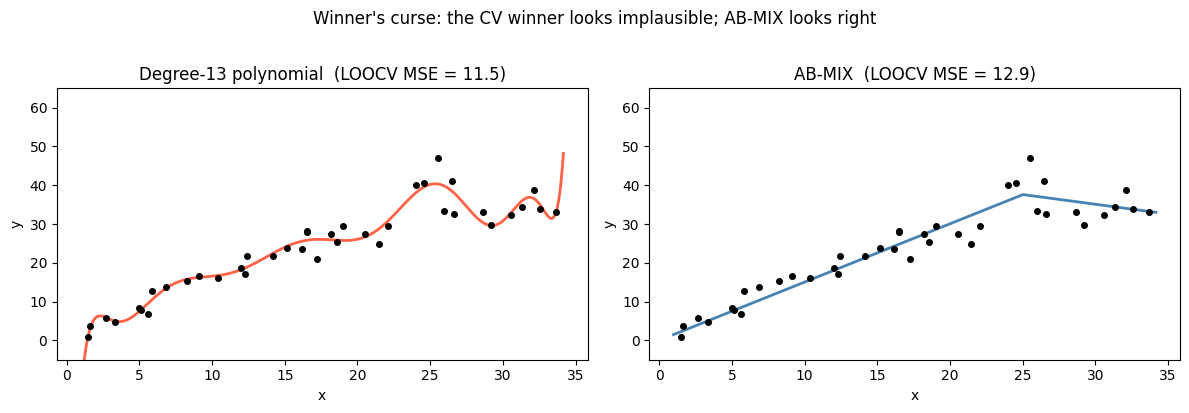

In [9]:
all_degs    = np.arange(1, 14)
loocv_ext   = np.array([loocv_mse_poly(x, y, d) for d in all_degs])

print('LOOCV MSE for degrees 1–13:')
for d, m in zip(all_degs, loocv_ext):
    marker = '  <-- AB-MIX' if abs(m - abmix_loocv) < 1 else ''
    print(f'  degree {d:2d}: {m:6.1f}{marker}')
print(f'  AB-MIX:    {abmix_loocv:6.1f}')

winner_deg = int(all_degs[np.argmin(loocv_ext)])
c_winner   = Polynomial.fit(x, y, winner_deg)
print(f'\nCV winner: degree {winner_deg}  (LOOCV MSE = {loocv_ext.min():.1f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x, y, color='k', s=16, zorder=3)
axes[0].plot(x_plot, c_winner(x_plot), 'tomato', linewidth=2)
axes[0].set_xlabel('x');  axes[0].set_ylabel('y')
axes[0].set_title(f'Degree-{winner_deg} polynomial  (LOOCV MSE = {loocv_ext.min():.1f})')
axes[0].set_ylim(-5, 65)

axes[1].scatter(x, y, color='k', s=16, zorder=3)
axes[1].plot(x_plot, ab_mix(x_plot, x_opt_hat, y_max_hat), 'steelblue', linewidth=2)
axes[1].set_xlabel('x');  axes[1].set_ylabel('y')
axes[1].set_title(f'AB-MIX  (LOOCV MSE = {abmix_loocv:.1f})')
axes[1].set_ylim(-5, 65)

plt.suptitle("Winner's curse: the CV winner looks implausible; AB-MIX looks right", y=1.02)
plt.tight_layout()
plt.show()

The degree-13 curve narrowly wins on LOOCV but looks physically implausible.  We found it by trawling through 13 candidate degrees — the more candidates we try, the more likely one will fluke a good score on *this* dataset.  The case for AB-MIX rests on both its CV performance *and* its physical motivation, whereas the case for degree 13 rests on CV alone.  Background knowledge breaks the tie.

---
## 7 · Test-set evaluation

> **Book link — §2.6.**  The inventors supply 15 new data points — a fresh test set $D_{\text{test}}$ — that were not used at any stage of model selection.  This lets us get an unbiased read on the true future performance of each prediction strategy.

Test set: n = 15 points
Test-set MSE  —  AB-MIX:           57.4
Test-set MSE  —  Degree 13: 176.2


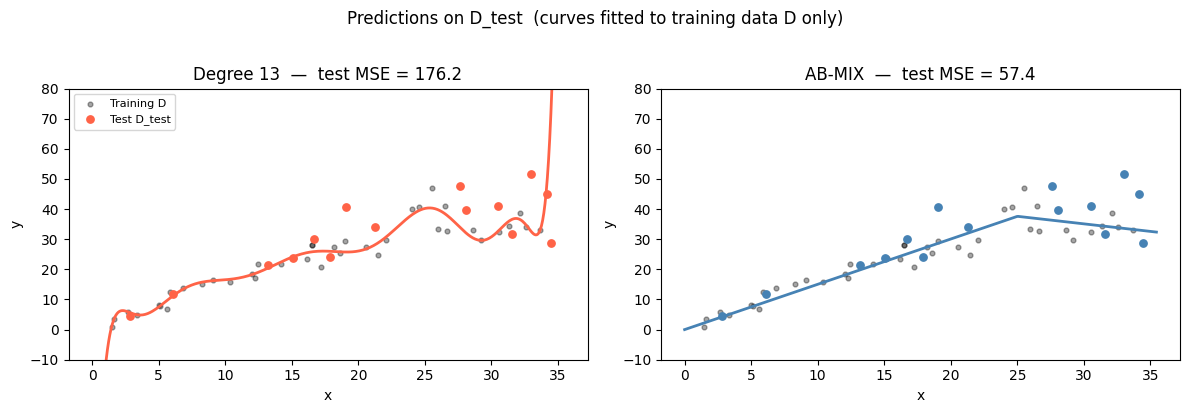

In [10]:
D_test = pd.read_csv(DATA_PATH + 'queens_test_data.csv')
x_test = D_test['x'].values
y_test = D_test['y'].values
print(f'Test set: n = {len(x_test)} points')

mse_abmix  = float(np.mean((y_test - ab_mix(x_test, x_opt_hat, y_max_hat)) ** 2))
mse_winner = float(np.mean((y_test - c_winner(x_test))          ** 2))
print(f'Test-set MSE  —  AB-MIX:           {mse_abmix:.1f}')
print(f'Test-set MSE  —  Degree {winner_deg}: {mse_winner:.1f}')

x_plot2 = np.linspace(0, max(x_test.max(), x.max()) + 1, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_hat, c_poly, color, label, mse in zip(
        axes,
        [c_winner(x_test), ab_mix(x_test, x_opt_hat, y_max_hat)],
        [c_winner,                     None],
        ['tomato',                     'steelblue'],
        [f'Degree {winner_deg}',       'AB-MIX'],
        [mse_winner,                   mse_abmix]):
    ax.scatter(x,      y,      color='k',     s=12, alpha=0.35, label='Training D')
    ax.scatter(x_test, y_test, color=color,   s=28, zorder=3,   label='Test D_test')
    if c_poly is not None:
        ax.plot(x_plot2, c_poly(x_plot2), color=color, lw=2)
    else:
        ax.plot(x_plot2, ab_mix(x_plot2, x_opt_hat, y_max_hat), color=color, lw=2)
    ax.set_xlabel('x');  ax.set_ylabel('y')
    ax.set_title(f'{label}  —  test MSE = {mse:.1f}')
    ax.set_ylim(-10, 80)

axes[0].legend(fontsize=8)
plt.suptitle('Predictions on D_test  (curves fitted to training data D only)', y=1.02)
plt.tight_layout()
plt.show()

AB-MIX wins convincingly on the held-out test data — confirming both that background knowledge was well-placed and that the winner's apparent CV advantage was indeed a fluke.

---
## 8 · Bootstrapping

> **Book link — §2.7.**  Now that $D_{\text{test}}$ has arrived it would be wasteful not to use it.  We merge the two datasets into $D_{\text{final}}$ (55 points) and fit AB-MIX to it.  To quantify uncertainty in the fitted parameters, we use **bootstrapping**: resample $D_{\text{final}}$ with replacement to generate many 'replica' datasets, fit AB-MIX to each, and read off the spread of the resulting parameter estimates.

D_final: n = 55 points
D_final fit:  x_opt = 25.5,  y_max = 39.8

Bootstrap uncertainty  (n_boot = 500):
  x_opt = 25.5 ± 1.3
  y_max = 39.8 ± 1.6


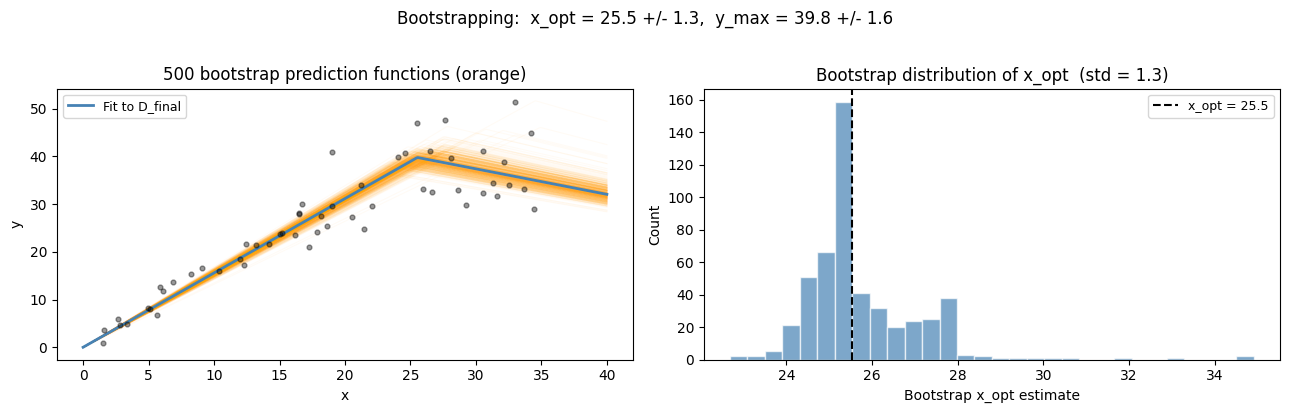

In [11]:
x_final = np.concatenate([x, x_test])
y_final = np.concatenate([y, y_test])
n_final = len(x_final)
print(f'D_final: n = {n_final} points')

x_opt_final, y_max_final = fit_abmix(x_final, y_final)
print(f'D_final fit:  x_opt = {x_opt_final:.1f},  y_max = {y_max_final:.1f}')

n_boot = 500
x_opt_boot = np.zeros(n_boot)
y_max_boot = np.zeros(n_boot)

for b in range(n_boot):
    idx = rng.integers(0, n_final, size=n_final)
    x_opt_boot[b], y_max_boot[b] = fit_abmix(x_final[idx], y_final[idx],
                                              x0=(x_opt_final, y_max_final))

print(f'\nBootstrap uncertainty  (n_boot = {n_boot}):')
print(f'  x_opt = {x_opt_final:.1f} ± {x_opt_boot.std():.1f}')
print(f'  y_max = {y_max_final:.1f} ± {y_max_boot.std():.1f}')

x_plot3 = np.linspace(0, 40, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for b in range(n_boot):
    axes[0].plot(x_plot3, ab_mix(x_plot3, x_opt_boot[b], y_max_boot[b]),
                 color='orange', alpha=0.04, linewidth=0.8)
axes[0].plot(x_plot3, ab_mix(x_plot3, x_opt_final, y_max_final),
             'steelblue', linewidth=2, label='Fit to D_final', zorder=3)
axes[0].scatter(x_final, y_final, color='k', s=12, alpha=0.4, zorder=4)
axes[0].set_xlabel('x');  axes[0].set_ylabel('y')
axes[0].set_title('500 bootstrap prediction functions (orange)')
axes[0].legend(fontsize=9)

axes[1].hist(x_opt_boot, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(x_opt_final, color='k', linestyle='--', linewidth=1.5,
                label=f'x_opt = {x_opt_final:.1f}')
axes[1].set_xlabel('Bootstrap x_opt estimate')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Bootstrap distribution of x_opt  (std = {x_opt_boot.std():.1f})')
axes[1].legend(fontsize=9)

plt.suptitle(f'Bootstrapping:  x_opt = {x_opt_final:.1f} +/- {x_opt_boot.std():.1f},  '
             f'y_max = {y_max_final:.1f} +/- {y_max_boot.std():.1f}', y=1.02)
plt.tight_layout()
plt.show()

The spread of bootstrap curves quantifies our uncertainty about the *shape* of the prediction function, not about individual future $y$ values.  Even with 55 points, $x_{\mathrm{opt}}$ is known to about $\pm 1$–$2$ units.

---
## Exercises

### Exercise 1 — $k$-fold cross-validation

LOOCV fits $n$ models (one per data point), which is fine here but expensive for large datasets.  A practical alternative is **$k$-fold CV**: randomly split the data into $k$ roughly equal 'folds', hold each fold out in turn as a validation set while fitting to the remaining $k-1$ folds, and average the squared errors over all held-out points.

Implement 5-fold CV for polynomial degrees 1–7 on the training data.  Plot the 5-fold CV MSE curve alongside the LOOCV curve already computed in §4.  Do both methods agree on the sweet-spot degree?

*(Hint: `np.array_split` is useful for dividing indices into folds.)*

In [11]:
# Your answer here


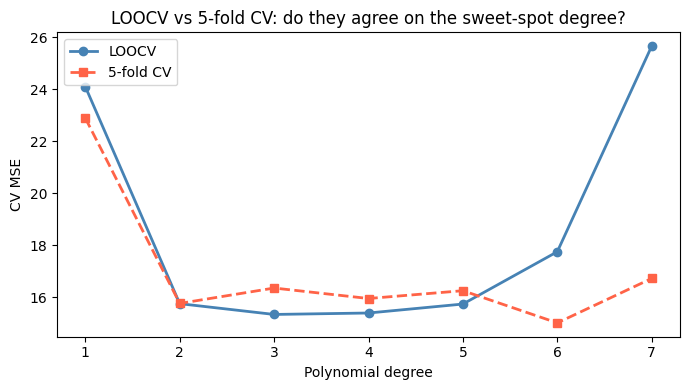

LOOCV sweet spot:   degree 3
5-fold CV sweet spot: degree 6

Degree | LOOCV MSE | 5-fold CV MSE
  1    |    24.1   |    22.9
  2    |    15.7   |    15.8
  3    |    15.3   |    16.3
  4    |    15.4   |    15.9
  5    |    15.7   |    16.2
  6    |    17.7   |    15.0
  7    |    25.7   |    16.7


In [12]:
# Solution
def kfold_cv_mse(x, y, degree, k=5, seed=7):
    n   = len(x)
    idx = np.random.default_rng(seed).permutation(n)
    sq_errs = []
    for fold in np.array_split(idx, k):
        val  = np.zeros(n, dtype=bool);  val[fold] = True
        c    = Polynomial.fit(x[~val], y[~val], degree)
        sq_errs.extend((y[fold] - c(x[fold])) ** 2)
    return float(np.mean(sq_errs))

degs_ex = np.arange(1, 8)
kfold5  = np.array([kfold_cv_mse(x, y, d) for d in degs_ex])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degs_ex, loocv_poly, 'o-', color='steelblue', lw=2, label='LOOCV')
ax.plot(degs_ex, kfold5,         's--', color='tomato',    lw=2, label='5-fold CV')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('CV MSE')
ax.set_title('LOOCV vs 5-fold CV: do they agree on the sweet-spot degree?')
ax.legend()
plt.tight_layout()
plt.show()

print(f'LOOCV sweet spot:   degree {degs_ex[np.argmin(loocv_poly)]}')
print(f'5-fold CV sweet spot: degree {degs_ex[np.argmin(kfold5)]}')
print()
print('Degree | LOOCV MSE | 5-fold CV MSE')
for d, lo, kf in zip(degs_ex, loocv_poly, kfold5):
    print(f'  {d}    |   {lo:5.1f}   |   {kf:5.1f}')

### Exercise 2 — Learning curves

**More data is one cure for overfitting.**  To see this, subsample the training data to sizes $n \in \{8, 12, 16, 20, 25, 30, 35, 40\}$ (take the first $n$ points of a fixed random permutation).  For each $n$, compute the LOOCV MSE for a linear model (degree 1) and a cubic model (degree 3).

Plot the two **learning curves** (LOOCV MSE vs $n$) on the same axes.  At small $n$, which model overfits more?  What happens as $n$ grows?

In [13]:
# Your answer here


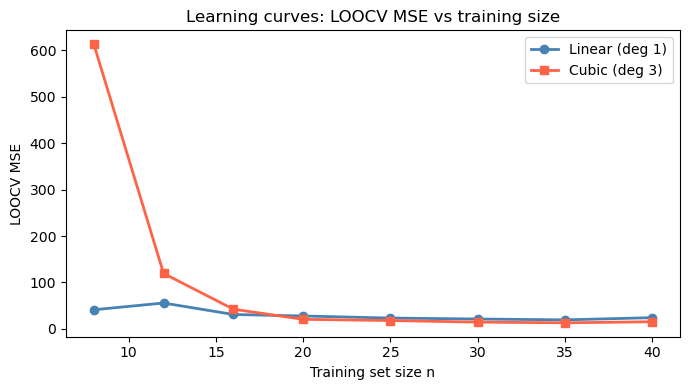

In [14]:
# Solution
perm   = rng.permutation(len(x))
x_p, y_p = x[perm], y[perm]

sizes      = [8, 12, 16, 20, 25, 30, 35, 40]
lc_deg1    = [loocv_mse_poly(x_p[:n], y_p[:n], 1) for n in sizes]
lc_deg3    = [loocv_mse_poly(x_p[:n], y_p[:n], 3) for n in sizes]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, lc_deg1, 'o-', color='steelblue', lw=2, label='Linear (deg 1)')
ax.plot(sizes, lc_deg3, 's-', color='tomato',    lw=2, label='Cubic (deg 3)')
ax.set_xlabel('Training set size n')
ax.set_ylabel('LOOCV MSE')
ax.set_title('Learning curves: LOOCV MSE vs training size')
ax.legend()
plt.tight_layout()
plt.show()

# At small n the cubic overfits badly (high LOOCV MSE); both curves fall with more data
# and converge as the dataset grows — the cubic catches up once it has enough data to
# constrain its extra parameters.

### Exercise 3 — Bootstrap uncertainty and sample size

In §8 we bootstrapped $D_{\text{final}}$ ($n = 55$) to quantify uncertainty in $\hat{x}_{\text{opt}}$.  Does having less data lead to greater uncertainty, as we would intuitively expect?

Test this using the training data alone.  Take a fixed random permutation of $D$ and bootstrap two subsets: $n = 20$ (first 20 points) and $n = 40$ (all 40 points).  For each, draw 500 bootstrap replicates, fit AB-MIX, and record $\hat{x}_{\text{opt}}$.  Plot the two histograms side by side and compare their spreads.

In [15]:
# Your answer here


Bootstrap std of x_opt  |  n = 20: 1.03
Bootstrap std of x_opt  |  n = 40: 0.56


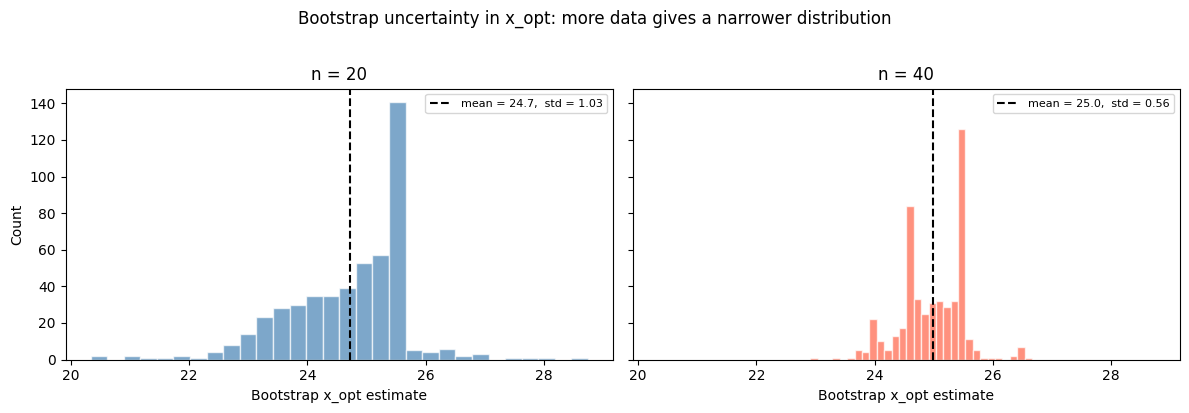

In [14]:
# Solution
perm_ex3 = np.random.default_rng(99).permutation(len(x))
x_sub20, y_sub20 = x[perm_ex3[:20]], y[perm_ex3[:20]]
x_sub40, y_sub40 = x[perm_ex3],      y[perm_ex3]        # all 40

def bootstrap_xopt(x_data, y_data, n_boot=500, seed=0):
    rng_b = np.random.default_rng(seed)
    n = len(x_data)
    results = np.zeros(n_boot)
    for b in range(n_boot):
        idx = rng_b.integers(0, n, size=n)
        results[b] = fit_abmix(x_data[idx], y_data[idx])[0]
    return results

boot20 = bootstrap_xopt(x_sub20, y_sub20, seed=0)
boot40 = bootstrap_xopt(x_sub40, y_sub40, seed=1)

print(f'Bootstrap std of x_opt  |  n = 20: {boot20.std():.2f}')
print(f'Bootstrap std of x_opt  |  n = 40: {boot40.std():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)
for ax, boot, n_lab, color in zip(axes,
                                   [boot20, boot40], [20, 40],
                                   ['steelblue', 'tomato']):
    ax.hist(boot, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(boot.mean(), color='k', linestyle='--', linewidth=1.5,
               label=f'mean = {boot.mean():.1f},  std = {boot.std():.2f}')
    ax.set_xlabel('Bootstrap x_opt estimate')
    ax.set_title(f'n = {n_lab}')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('Bootstrap uncertainty in x_opt: more data gives a narrower distribution', y=1.02)
plt.tight_layout()
plt.show()

# The n=20 bootstrap is clearly wider than n=40: with fewer data points, the bootstrap
# replicates vary more, and our estimate of x_opt is correspondingly less precise.
# This is the intuitive link between sample size and estimation uncertainty.